In [1]:
%load_ext autoreload
%autoreload 2


In [ ]:
import os
import sys

PDM_DIR = os.environ.get('PDM_DIR', '../../../PDM')
sys.path.append(f'{PDM_DIR}/src')
import verbatim_eval.controlled_expr as _ce
import verbatim_eval.rouge_ttr as _rt
import verbatim_eval.utils as _ut
sys.modules['controlled_expr'] = _ce  # needed for pickle deserialization
sys.modules['rouge_ttr'] = _rt
sys.modules['utils'] = _ut

sys.path.insert(0, '../..')
from attn_bench.plotting import model_registry
from attn_bench.plotting.data_loading import load_mem_results_by_name, load_mem_results_scores_grid
from attn_bench.plotting.heatmap import plot_models_heatmap, plot_models_heatmap_panel


# Memorization results, scf1-trained models

Every model here is trained (not just inferred) with `--rope-scaling-factor 1` -- full, gated,
sink and the three SWA window sizes all share the same scf1 config (8 nodes, TP=1, MBS=3,
GBS=288, 18141 steps). `gdn` is the original (non-scf1, scf=8-implicit) GDN baseline -- kept
as-is since RoPE scaling doesn't affect it (no scf8/scf1 split exists for GDN, see
`scf8_variant()` in `model_registry.py`).

Single heatmap at offset=0, prefix=500, suffix=500: rows = repetitions, columns = models.


In [3]:
MODELS = ['full-scf1', 'gated-scf1', 'sink-scf1', 'swa-w256-scf1', 'swa-w1024-scf1', 'swa-w4096-scf1', 'gdn']
OFFSET, PREFIX, SUFFIX = 0, 500, 500

exp_names = {m: model_registry.MODELS[m] for m in MODELS}
results = load_mem_results_by_name(exp_names, model_registry.MEM_RESULTS_DIR,
                                   offset=OFFSET, prefix=PREFIX, suffix=SUFFIX)


### Rouge-L

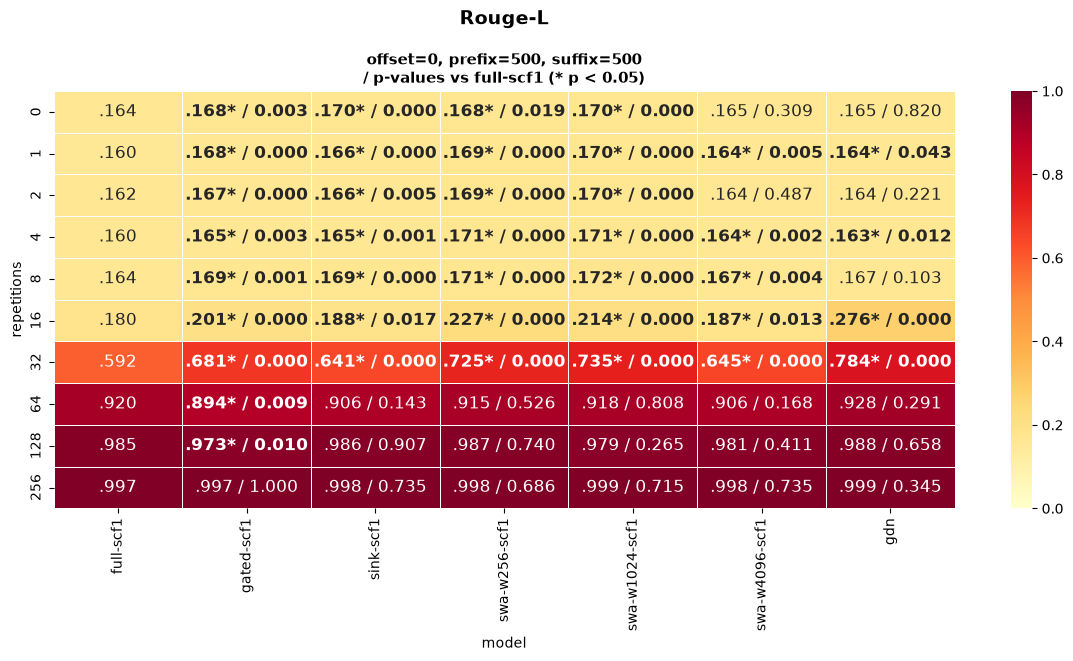

In [4]:
plot_models_heatmap(
    results, 'Rouge-L', offset=OFFSET, prefix=PREFIX, suffix=SUFFIX,
    reference='full-scf1', models=MODELS,
)


## Attention families vs. offset

`full`, `gated`, `sink`, `swa-w1024`, `swa-w256`, `gdn` -- one heatmap panel per offset, fixed
prefix=500, suffix=500.


In [17]:
FAMILY_MODELS = ['full-scf1', 'gated-scf1', 'sink-scf1', 'swa-w1024-scf1', 'swa-w256-scf1', 'gdn']
FAMILY_OFFSETS = [0, 5, 12, 25, 50, 100, 1000, 3000]

family_results_grid = load_mem_results_scores_grid(
    FAMILY_OFFSETS, [500], [500], models=FAMILY_MODELS, results_base=model_registry.MEM_RESULTS_DIR
)


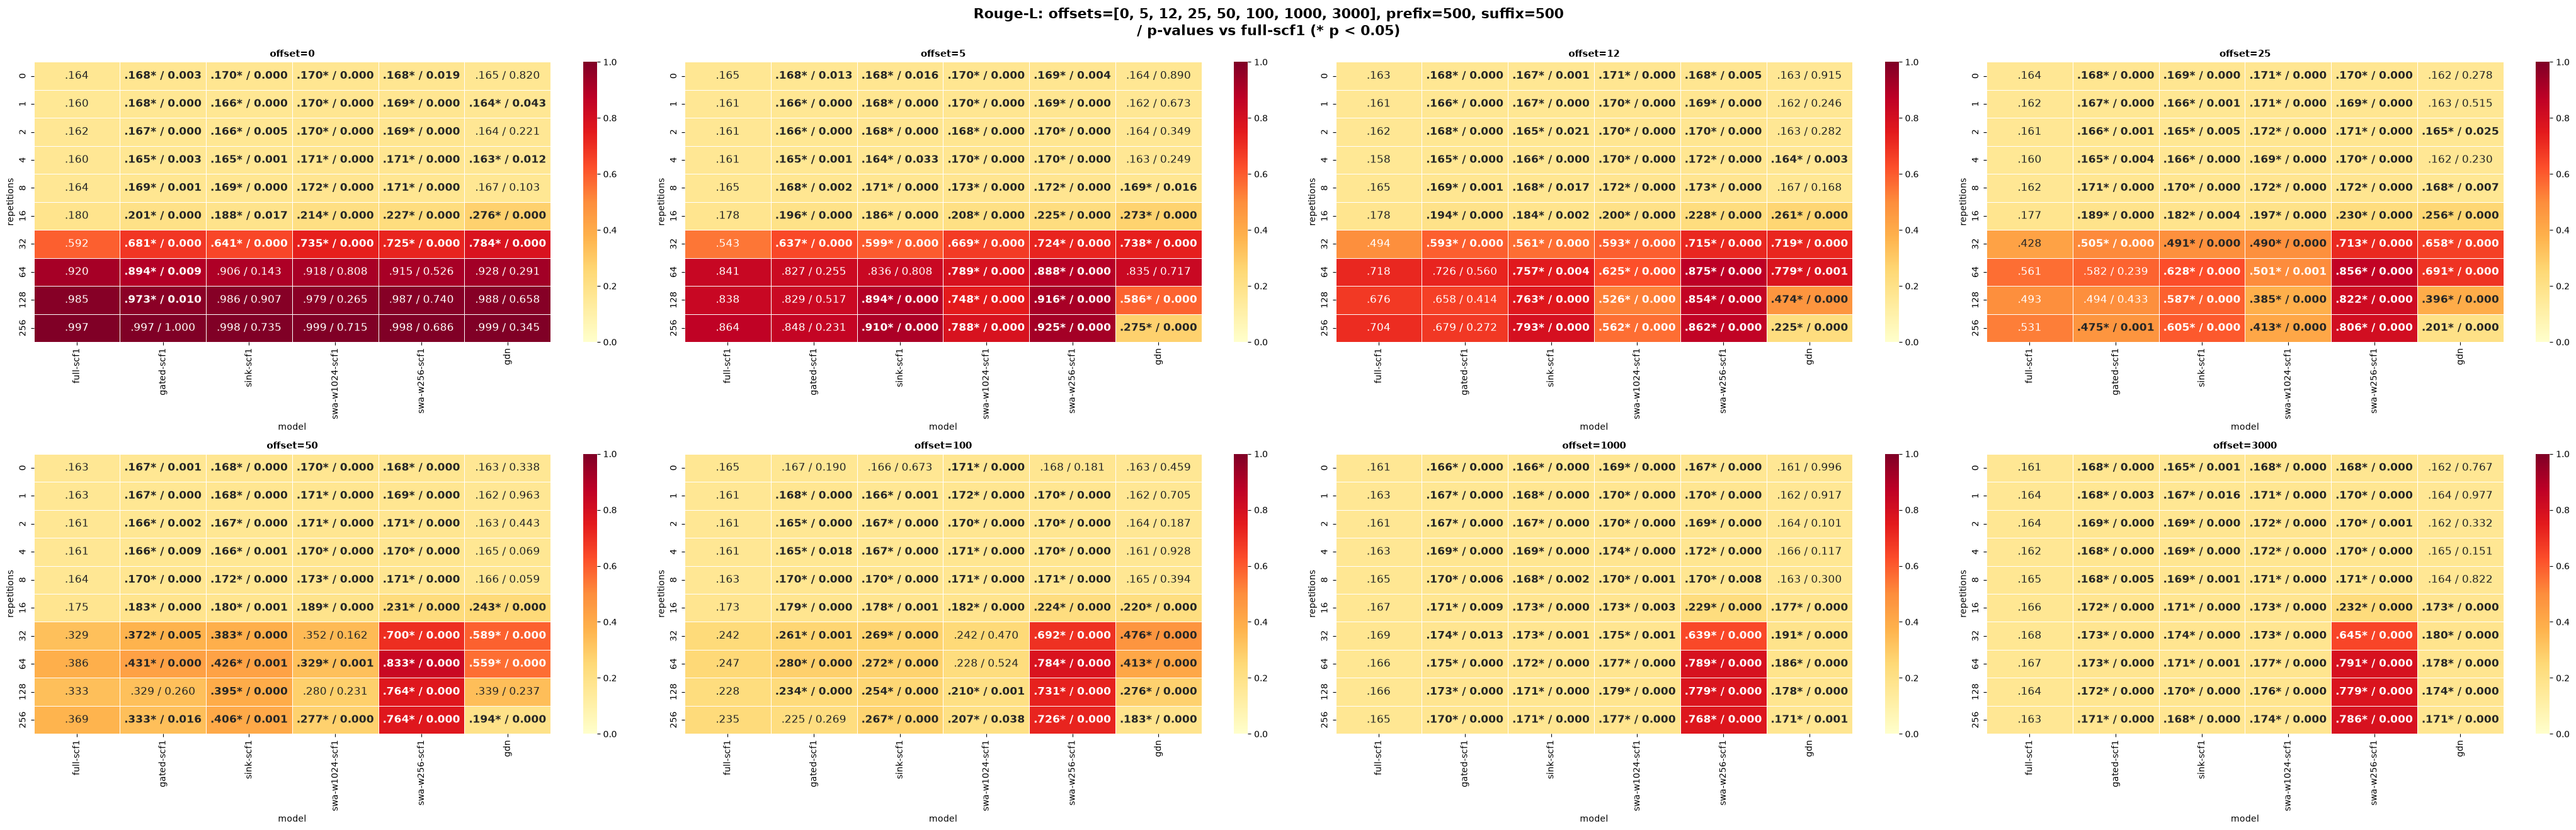

In [18]:
plot_models_heatmap_panel(
    family_results_grid, 'Rouge-L', panels='offset', values=FAMILY_OFFSETS, fixed_prefix=500, fixed_suffix=500,
    reference='full-scf1', models=FAMILY_MODELS, ncols=4
)
